
## Reproducibility Notes

**Random Seed**: Set to `42` for consistent results across runs

**Simulation Parameters**: 
- **Days**: 365 (1 year)
- **Players**: ~1,580 total
  - 1,500 procedural players across 5 core strategies (~300 each via random sampling)
  - 60 adaptive players (3 sub-types × 20: Expert, Scrapper, Desperate)
  - 20 benchmark players + 1 perfect player

**Daily Difficulty** (drawn randomly each day, visible to all strategies before they act):
| Tier   | Clue Value | Probability | Accuracy modifier |
|--------|-----------|-------------|-------------------|
| Low    | 100 pts   | 35%         | +5%               |
| Medium | 200 pts   | 40%         | ±0%               |
| High   | 300 pts   | 25%         | −20%              |

**Core Strategies**: Troll (jinx), Rester (rest), Thief (steal), Random (mixed), Passive (no powerups), Adaptive (near-optimal decision tree)

These choices ensure:
1. **Consistent results** — Same seed produces identical outcomes
2. **Narrow confidence intervals** — Large sample size reduces statistical variance
3. **Reliable strategy comparison** — Clear winners and losers with minimal overlap


# Powerup Simulation Analysis

This notebook runs the simulation logic defined in `simulate_powerups.py` and visualizes the results with 95% Confidence Intervals.

## Setup

In [1]:
import sys
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Add current directory to path to import script
sys.path.append(os.getcwd())

from simulate_powerups import (
    run_simulation,
    ProceduralStrategy,
    BenchmarkStrategy,
    AdaptiveStrategy,
    DIFFICULTY_WEIGHTS,
    DIFFICULTY_VALUES,
    SIMULATION_DAYS,
)

# Set Plot Style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
def get_rank_palette(df, cat_col, val_col="Score Ratio"):
    """
    Returns a palette dictionary where:
    1st (highest mean, non-Benchmark) -> Gold
    2nd -> Silver
    3rd -> Bronze
    Others -> Muted Blue
    Benchmark -> Muted Gray (reference, not ranked)
    """
    # Rank only real strategies; Benchmark is a reference tool, not a competitor
    means = (
        df[df[cat_col] != "Benchmark"]
        .groupby(cat_col)[val_col]
        .mean()
        .sort_values(ascending=False)
    )
    ranks = means.index.tolist()

    palette = {}
    medal_colors = {0: "#FFD700", 1: "#C0C0C0", 2: "#CD7F32"}
    benchmark_color = "#A0A0A0"  # Muted gray — comparison reference only
    default_color = "#5975A4"  # Muted Blue

    for i, cat in enumerate(ranks):
        palette[cat] = medal_colors.get(i, default_color)

    # Always override Benchmark regardless of its value ranking
    if "Benchmark" in df[cat_col].values:
        palette["Benchmark"] = benchmark_color

    return palette


def add_bar_labels(ax, fmt="%.3f"):
    """Adds labels inside the bars in a bar plot."""
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, label_type="edge", padding=-50)

## Simulate

In [3]:
# Run the Simulation
import random
import numpy as np
from tqdm.auto import tqdm

# Set Random Seed for Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Running Simulation... (This may take a moment)")

with tqdm(total=SIMULATION_DAYS, desc="Simulating days", unit="day") as pbar:
    players, strategies, daily_records = run_simulation(
        return_data=True,
        seed=SEED,
        on_day_complete=pbar.update,
    )

print(
    f"Simulation Complete. Processed {len(players)} players, {len(daily_records):,} daily observations."
)

c:\Users\Blake\anaconda3\envs\jbot\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running Simulation... (This may take a moment)


Simulating days:   0%|          | 1/365 [00:00<01:01,  5.94day/s]

Starting simulation for 365 days...


Simulating days: 100%|██████████| 365/365 [01:09<00:00,  5.26day/s]

Simulation Complete. Processed 1581 players, 192,882 daily observations.


In [4]:
# Build per-day DataFrame for difficulty analysis
daily_df = pd.DataFrame(daily_records)

# Exclude Benchmark from difficulty charts — it doesn't change behaviour by design
daily_df = daily_df[daily_df["core_strategy"] != "Benchmark"]

# Map None powerup_type to "none" for cleaner grouping
daily_df["powerup_type"] = daily_df["powerup_type"].fillna("none")

# Ordered difficulty axis
daily_df["difficulty"] = pd.Categorical(
    daily_df["difficulty"], categories=["Low", "Medium", "High"], ordered=True
)

In [5]:
# Build DataFrame
data = []

# Calculate Benchmark Mean for Ratio
benchmark_scores = [
    p.score for pid, p in players.items() if strategies[pid].name == "Benchmark"
]
benchmark_mean = (
    sum(benchmark_scores) / len(benchmark_scores) if benchmark_scores else 1
)

for pid, p in players.items():
    strat = strategies[pid]

    row = {
        "Name": p.name,
        "Score": p.score,
        "Score Ratio": p.score / benchmark_mean,
        "Streak": p.answer_streak,
        "Strategy Type": strat.name,
    }

    # Extract Dimensions
    if isinstance(strat, ProceduralStrategy):
        row["Core Strategy"] = strat.core_strategy
        row["Speed"] = strat.speed
        row["Correctness"] = strat.correctness
        row["Aggression"] = strat.aggression
    elif isinstance(strat, BenchmarkStrategy):
        row["Core Strategy"] = "Benchmark"
        row["Speed"] = "N/A"
        row["Correctness"] = "N/A"
        row["Aggression"] = "N/A"
    else:
        # Fallback
        row["Core Strategy"] = strat.name
        row["Speed"] = "N/A"
        row["Correctness"] = "N/A"
        row["Aggression"] = "N/A"

    data.append(row)

df = pd.DataFrame(data)

# Benchmark first (it's a reference), then strategies ranked highest → lowest Score Ratio
_non_benchmark_order = (
    df[df["Core Strategy"] != "Benchmark"]
    .groupby("Core Strategy")["Score Ratio"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)
ranked_strategy_order = ["Benchmark"] + _non_benchmark_order

df.head()

,Name,Score,Score Ratio,Streak,Strategy Type,Core Strategy,Speed,Correctness,Aggression
0,Benchmark_1,80965,1.021307,338,Benchmark,Benchmark,N/A,N/A,N/A
1,Benchmark_2,77960,0.983402,325,Benchmark,Benchmark,N/A,N/A,N/A
2,Benchmark_3,80365,1.013739,332,Benchmark,Benchmark,N/A,N/A,N/A
3,Benchmark_4,78590,0.991349,329,Benchmark,Benchmark,N/A,N/A,N/A
4,Benchmark_5,80310,1.013045,333,Benchmark,Benchmark,N/A,N/A,N/A


## Results by dimension

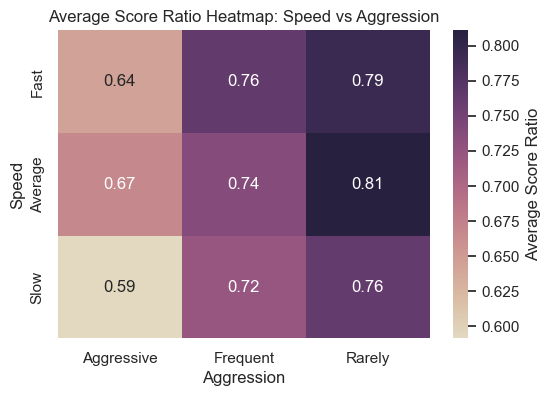

In [6]:
# Heatmap: Speed vs Aggression (Average Score Ratio)
# Filter for procedural only
proc_df = df[df["Speed"] != "N/A"]

heatmap_data_agg = proc_df.pivot_table(
    index="Speed", columns="Aggression", values="Score Ratio", aggfunc="mean"
)

# Reorder indices for better readability
speed_order = ["Fast", "Average", "Slow"]
agg_order = ["Aggressive", "Frequent", "Rarely"]
# Filter to existing
speed_order_agg = [s for s in speed_order if s in heatmap_data_agg.index]
agg_order_agg = [a for a in agg_order if a in heatmap_data_agg.columns]

heatmap_data_agg = heatmap_data_agg.reindex(
    index=speed_order_agg, columns=agg_order_agg
)

plt.figure(figsize=(6, 4))
sns.heatmap(
    heatmap_data_agg,
    annot=True,
    fmt=".2f",
    # https://seaborn.pydata.org/tutorial/color_palettes.html
    cmap=sns.color_palette("ch:s=-.2,r=.6", as_cmap=True),
    cbar_kws={"label": "Average Score Ratio"},
)
plt.title("Average Score Ratio Heatmap: Speed vs Aggression")
plt.show()

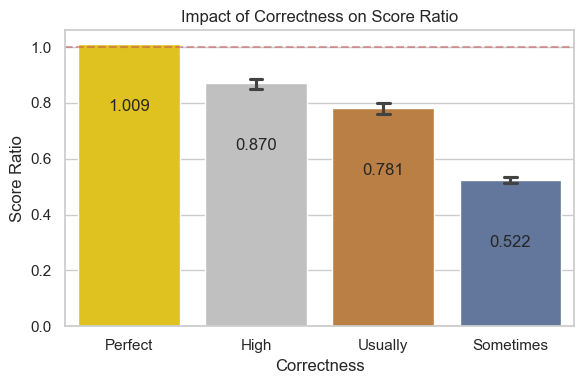

In [7]:
# Correctness Analysis — Speed and Aggression are covered by the heatmap above
dim_df = df[df["Speed"] != "N/A"]

acc_order = ["Perfect", "High", "Usually", "Sometimes"]
acc_pal = get_rank_palette(dim_df, "Correctness", "Score Ratio")

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=dim_df,
    x="Correctness",
    y="Score Ratio",
    order=acc_order,
    errorbar=("ci", 95),
    capsize=0.1,
    hue="Correctness",
    palette=acc_pal,
    legend=False,
)
ax.axhline(1.0, color="r", linestyle="--", alpha=0.5, label="Benchmark")
add_bar_labels(ax, fmt="%.3f")
plt.title("Impact of Correctness on Score Ratio")
plt.tight_layout()
plt.show()

## Results by strategy

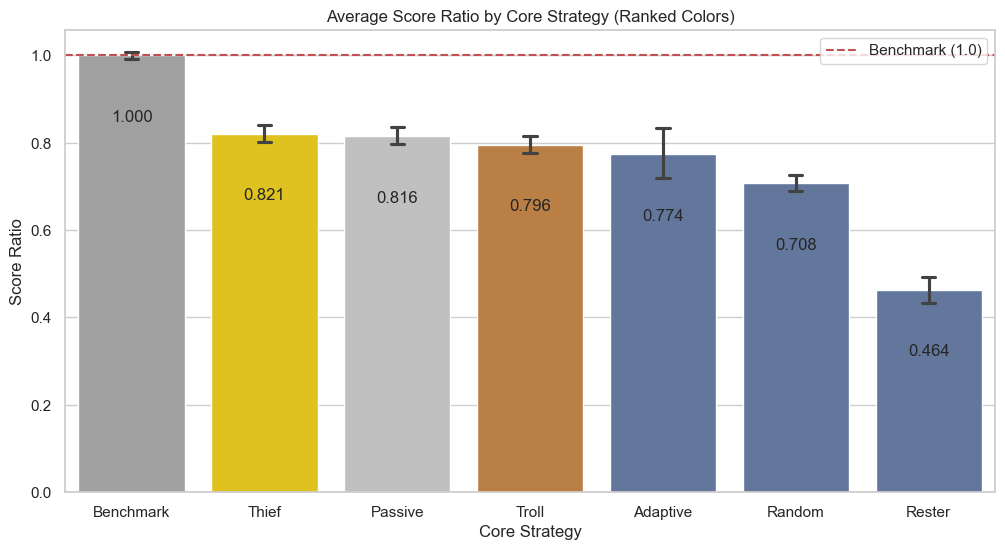

In [8]:
# Core Strategy Performance
plt.figure(figsize=(12, 6))

# Define palette based on rank (Gold, Silver, Bronze...)
palette = get_rank_palette(df, "Core Strategy", "Score Ratio")

# Using Score Ratio with modern seaborn API
ax = sns.barplot(
    data=df,
    x="Core Strategy",
    y="Score Ratio",
    order=ranked_strategy_order,
    errorbar=("ci", 95),
    capsize=0.1,
    hue="Core Strategy",
    palette=palette,
    legend=False,
)

# Add Labels
add_bar_labels(ax, fmt="%.3f")

plt.title("Average Score Ratio by Core Strategy (Ranked Colors)")
plt.axhline(1.0, color="r", linestyle="--", label="Benchmark (1.0)")
plt.legend()
plt.show()

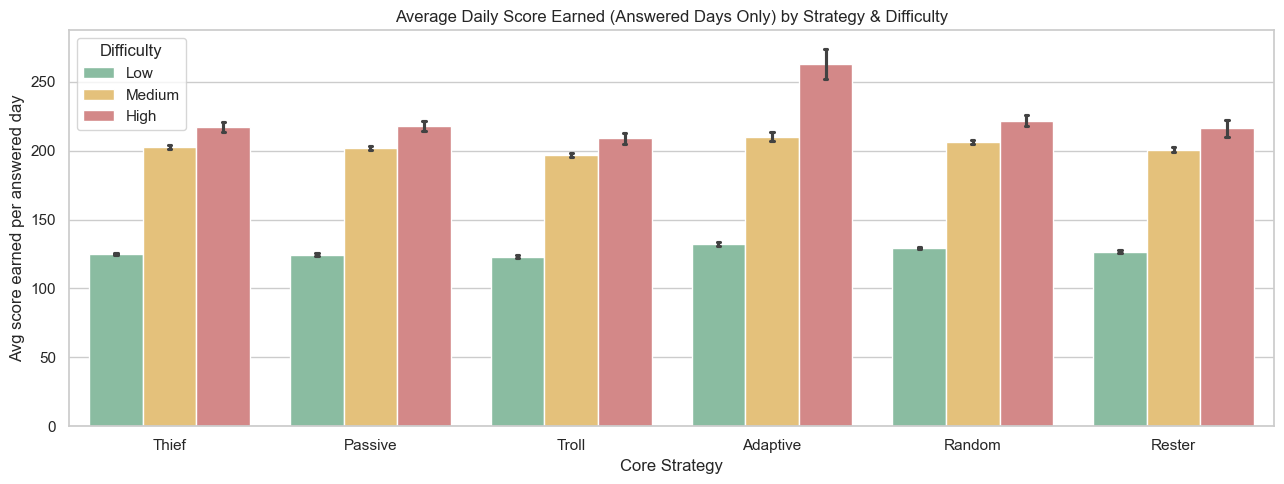

In [9]:
# Average daily score earned (excluding rest days) by difficulty per strategy.
# Shows which strategies extract the most value out of each tier when they do guess.
answered_df = daily_df[~daily_df["rested"]].copy()

plt.figure(figsize=(13, 5))
ax = sns.barplot(
    data=answered_df,
    x="core_strategy",
    y="score_earned",
    hue="difficulty",
    hue_order=["Low", "Medium", "High"],
    palette={"Low": "#82C4A0", "Medium": "#F5C76A", "High": "#E07B7B"},
    order=[
        s for s in ranked_strategy_order if s in answered_df["core_strategy"].unique()
    ],
    errorbar=("ci", 95),
    capsize=0.05,
)
plt.title("Average Daily Score Earned (Answered Days Only) by Strategy & Difficulty")
plt.xlabel("Core Strategy")
plt.ylabel("Avg score earned per answered day")
plt.legend(title="Difficulty")
plt.tight_layout()
plt.show()

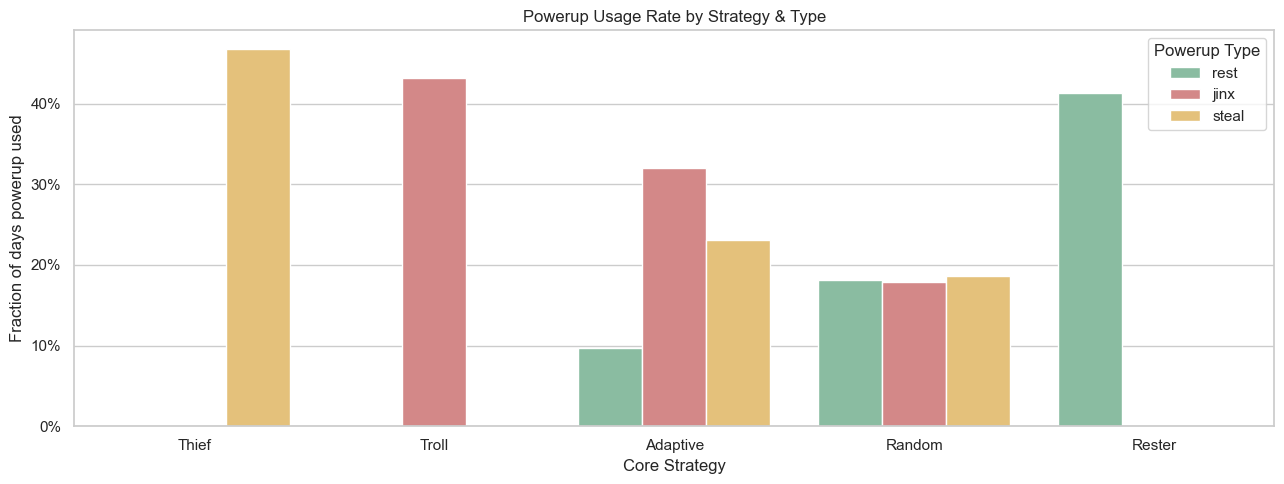

In [10]:
# Powerup Usage Rate by Strategy & Type
# Shows the fraction of (sampled) days each strategy fires each powerup
powerup_rate = (
    daily_df[daily_df["powerup_type"] != "none"]
    .groupby(["core_strategy", "powerup_type"])
    .size()
    .reset_index(name="count")
)
total_per_strat = daily_df.groupby("core_strategy").size().reset_index(name="total")
powerup_rate = powerup_rate.merge(total_per_strat, on="core_strategy")
powerup_rate["usage_rate"] = powerup_rate["count"] / powerup_rate["total"]

strat_order_filtered = [
    s for s in ranked_strategy_order if s in powerup_rate["core_strategy"].unique()
]

plt.figure(figsize=(13, 5))
ax = sns.barplot(
    data=powerup_rate,
    x="core_strategy",
    y="usage_rate",
    hue="powerup_type",
    hue_order=["rest", "jinx", "steal"],
    palette={"rest": "#82C4A0", "jinx": "#E07B7B", "steal": "#F5C76A"},
    order=strat_order_filtered,
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.title("Powerup Usage Rate by Strategy & Type")
plt.xlabel("Core Strategy")
plt.ylabel("Fraction of days powerup used")
plt.legend(title="Powerup Type")
plt.tight_layout()
plt.show()

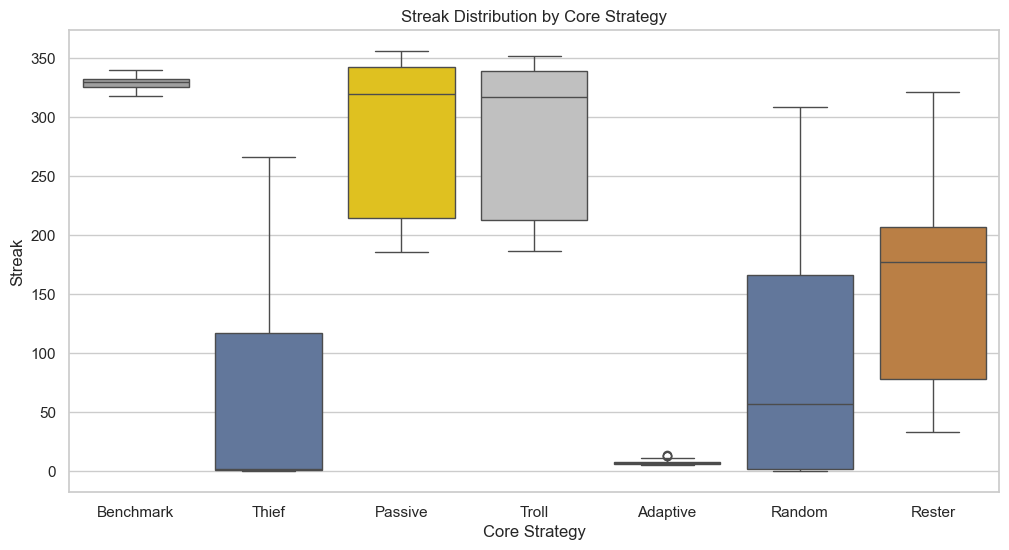

In [11]:
# Streak Distribution by Core Strategy (Benchmark first, then ranked)
plt.figure(figsize=(12, 6))
streak_pal = get_rank_palette(df, "Core Strategy", "Streak")
sns.boxplot(
    data=df,
    x="Core Strategy",
    y="Streak",
    order=ranked_strategy_order,
    hue="Core Strategy",
    palette=streak_pal,
    legend=False,
)
plt.title("Streak Distribution by Core Strategy")
plt.show()

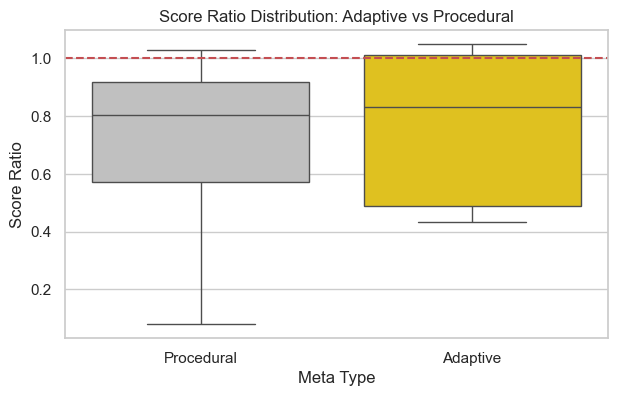

In [12]:
# Adaptive vs Procedural
# Is Adaptive better than the sum of its parts?
plt.figure(figsize=(7, 4))

comparison_df = df[
    df["Strategy Type"].str.contains("Adaptive|Passive|Thief|Troll|Rester|Random")
].copy()
comparison_df["Meta Type"] = comparison_df["Strategy Type"].apply(
    lambda x: "Adaptive" if "Adaptive" in x else "Procedural"
)

# Custom palette for just two items doesn't need bronze, but consistent with rank
meta_pal = get_rank_palette(comparison_df, "Meta Type", "Score Ratio")

sns.boxplot(
    data=comparison_df,
    x="Meta Type",
    y="Score Ratio",
    hue="Meta Type",
    palette=meta_pal,
    legend=False,
)
plt.title("Score Ratio Distribution: Adaptive vs Procedural")
plt.axhline(1.0, color="r", linestyle="--", label="Benchmark")
plt.show()

### Top Performers

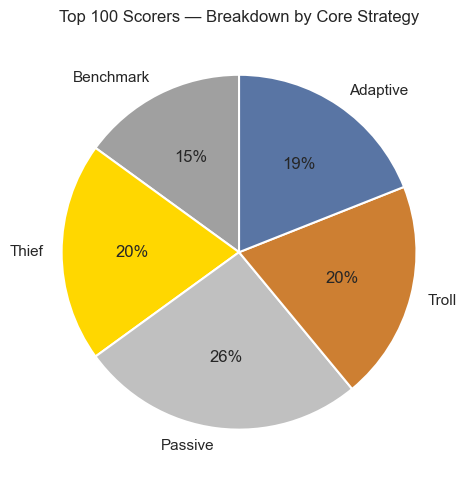

In [13]:
# Pie chart: which strategies dominate the top 100 scorers?
top100 = df.nlargest(100, "Score")
top100_counts = top100["Core Strategy"].value_counts()

# Preserve ranked order (Benchmark first) for consistent slice ordering
pie_order = [s for s in ranked_strategy_order if s in top100_counts.index]
counts = top100_counts.reindex(pie_order)

pie_pal = get_rank_palette(df, "Core Strategy", "Score Ratio")
colors = [pie_pal[s] for s in pie_order]

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    counts,
    labels=pie_order,
    colors=colors,
    autopct="%1.0f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
ax.set_title("Top 100 Scorers — Breakdown by Core Strategy")
plt.tight_layout()
plt.show()

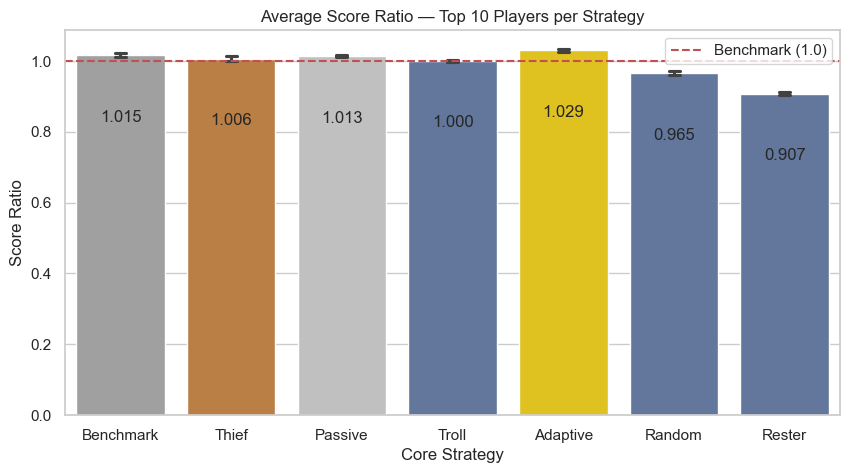

In [14]:
# Top 10 Score Ratio by Core Strategy — shows the ceiling of each strategy
top10_per_strat = (
    df.sort_values("Score Ratio", ascending=False)
    .groupby("Core Strategy", group_keys=False)
    .head(10)
    .reset_index(drop=True)
)

# Colors ranked by the top-10 subset; order stays consistent with all other charts
top10_palette = get_rank_palette(top10_per_strat, "Core Strategy", "Score Ratio")

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=top10_per_strat,
    x="Core Strategy",
    y="Score Ratio",
    order=ranked_strategy_order,
    errorbar=("ci", 95),
    capsize=0.1,
    hue="Core Strategy",
    palette=top10_palette,
    legend=False,
)
add_bar_labels(ax, fmt="%.3f")
plt.title("Average Score Ratio — Top 10 Players per Strategy")
plt.axhline(1.0, color="r", linestyle="--", label="Benchmark (1.0)")
plt.legend()
plt.show()

In [15]:
# Top 1 per strategy — single compact table
pd.set_option("display.float_format", "{:.3f}".format)

top1_rows = []
for strategy in ranked_strategy_order:
    strat_df = df[df["Core Strategy"] == strategy]
    if strat_df.empty:
        continue
    top1_rows.append(strat_df.nlargest(1, "Score").iloc[0])

top1_df = pd.DataFrame(top1_rows)[
    [
        "Core Strategy",
        "Name",
        "Score",
        "Score Ratio",
        "Streak",
        "Speed",
        "Correctness",
        "Aggression",
    ]
].reset_index(drop=True)

print("\nTop 1 Player per Core Strategy:\n")
print(top1_df.to_string(index=False))

pd.reset_option("display.float_format")


Top 1 Player per Core Strategy:

Core Strategy              Name  Score  Score Ratio  Streak   Speed Correctness Aggression
    Benchmark      Benchmark_18  81905        1.033     338     N/A         N/A        N/A
        Thief     Thief_FHR_612  81610        1.029     215    Fast        High     Rarely
      Passive   Passive_FHR_766  81515        1.028     356    Fast        High     Rarely
        Troll     Troll_FHF_282  80110        1.011     352    Fast        High   Frequent
     Adaptive Adaptive_Expert_9  83101        1.048       8    Fast        High   Frequent
       Random    Random_FHR_520  77936        0.983     301    Fast        High     Rarely
       Rester    Rester_AHR_856  72958        0.920     321 Average        High     Rarely


In [16]:
# Top Performers Analysis — top 15 individual players across all strategies
top_performers = df.sort_values("Score", ascending=False).head(15)

print("Top 15 Performing Players:")
display_cols = [
    "Name",
    "Score",
    "Score Ratio",
    "Streak",
    "Core Strategy",
    "Speed",
    "Correctness",
    "Aggression",
]
print(top_performers[display_cols].to_string(index=False))

Top 15 Performing Players:
              Name  Score  Score Ratio  Streak Core Strategy Speed Correctness Aggression
 Adaptive_Expert_9  83101     1.048251       8      Adaptive  Fast        High   Frequent
 Adaptive_Expert_3  81936     1.033556       7      Adaptive  Fast        High   Frequent
      Benchmark_18  81905     1.033165     338     Benchmark   N/A         N/A        N/A
Adaptive_Expert_19  81858     1.032572       9      Adaptive  Fast        High   Frequent
      Benchmark_19  81785     1.031651     340     Benchmark   N/A         N/A        N/A
Adaptive_Expert_10  81710     1.030705       9      Adaptive  Fast        High   Frequent
 Adaptive_Expert_1  81656     1.030024      11      Adaptive  Fast        High   Frequent
     Thief_FHR_612  81610     1.029443     215         Thief  Fast        High     Rarely
   Passive_FHR_766  81515     1.028245     356       Passive  Fast        High     Rarely
Adaptive_Expert_18  81485     1.027867      10      Adaptive  Fast       